In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from src.custom_kfold import CustomKFold
from src.sdee_statistics import calculate_nmae, calculate_mae
from src.train_dataset import get_X_y, train_model_cv
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import (
    SelectPercentile,
    f_regression,
    mutual_info_regression,
)
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import mutual_info_regression
import json
from src.get_folds_results import get_fold_results
from src.plot_results import plot_feature_frequency_per_fold


In [2]:
# load dataset heads:
dataset = "jira"
dataset_iteration_30 = pd.read_csv(f"datasets/{dataset}_iteration_30_features.csv")
dataset_iteration_30.head(1)

# setup model:
X, y = get_X_y(dataset_iteration_30)

custom_kfold = CustomKFold(n_splits=10, shuffle=False)
nmae_scorer = make_scorer(calculate_nmae, greater_is_better=False)
mae_scorer = make_scorer(calculate_mae, greater_is_better=False)

# train model
random_forest = RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42)

In [3]:
feature_title_mapping = {
    "vel_todo": "To-Do Velocity",
    "priority_freq_Major": "Frequency of Major Priority",
    "type_freq_Improvement": "Frequency of Improvement Type",
    "vel_starttime": "Start Time Velocity",
    "vel_inprogress": "In-Progress Velocity",
    "type_freq_Bug": "Frequency of Bug Type",
    "priority_freq_Critical": "Frequency of Critical Priority",
    "vel_added": "Added Velocity",
    "gunning_fog_freq_hard": "Frequency of Hard Gunning Fog",
    "no_issuetodo": "Number of To-Do Issues",
    "no_issues": "Total Number of Issues",
    "no_teammember": "Number of Team Members",
    "gunning_fog_freq_easy": "Frequency of Easy Gunning Fog",
    "type_freq_Task": "Frequency of Task Type",
    "no_issue_starttime": "Number of Issues at Start Time",
    "type_freq_Technical task": "Frequency of Technical Task Type",
    "no_issueinprogress": "Number of Issues In Progress",
    "no_fixversion_var": "Number of Fix Version Changes",
    "no_comment_std": "Standard Deviation of Number of Comments",
    "priority_freq_Minor": "Frequency of Minor Priority"
}

## SHAP

In [34]:
import shap
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)
rf = random_forest.fit(X_train, y_train)

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_train)

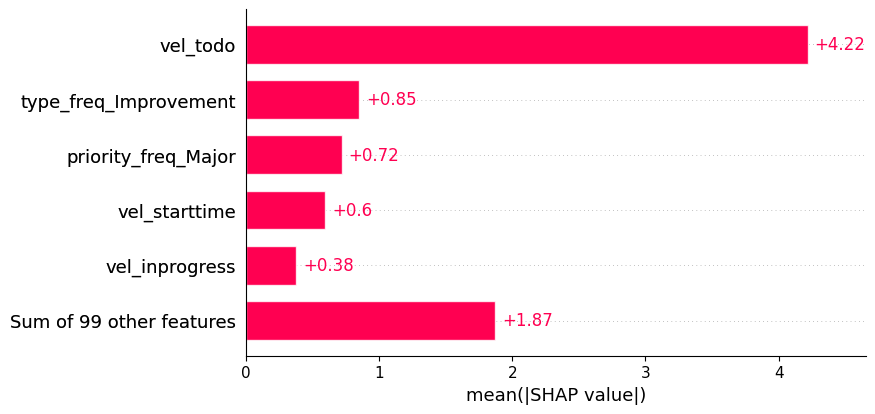

In [45]:
shap.plots.bar(shap_values, max_display=6)

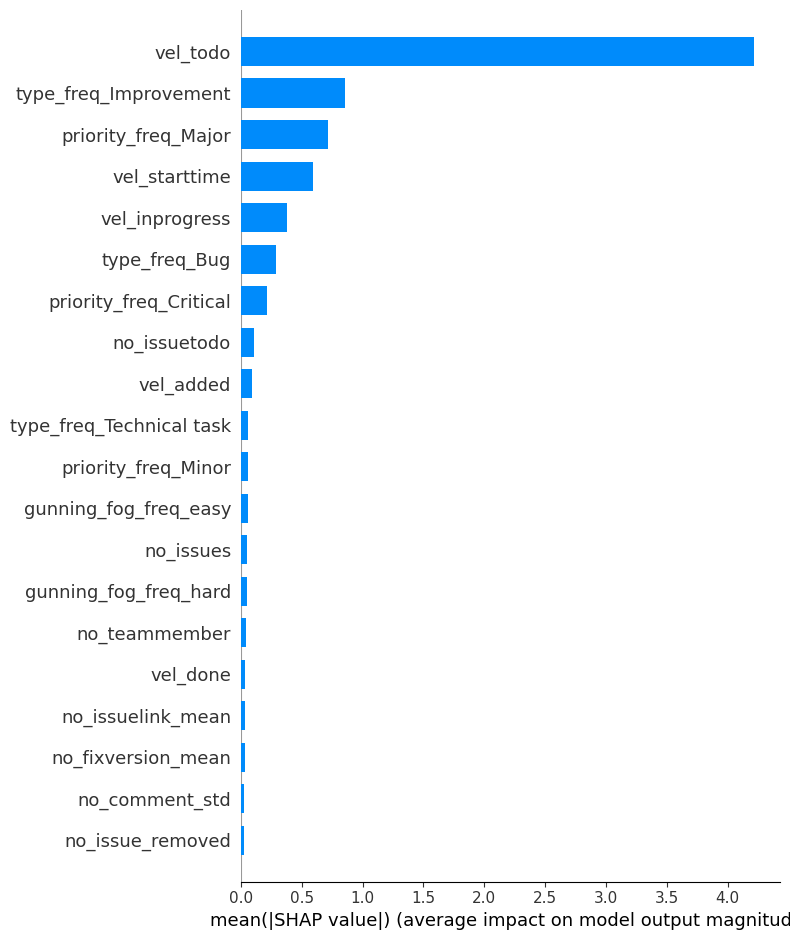

In [5]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

AssertionError: Feature and SHAP matrices must have the same number of rows!

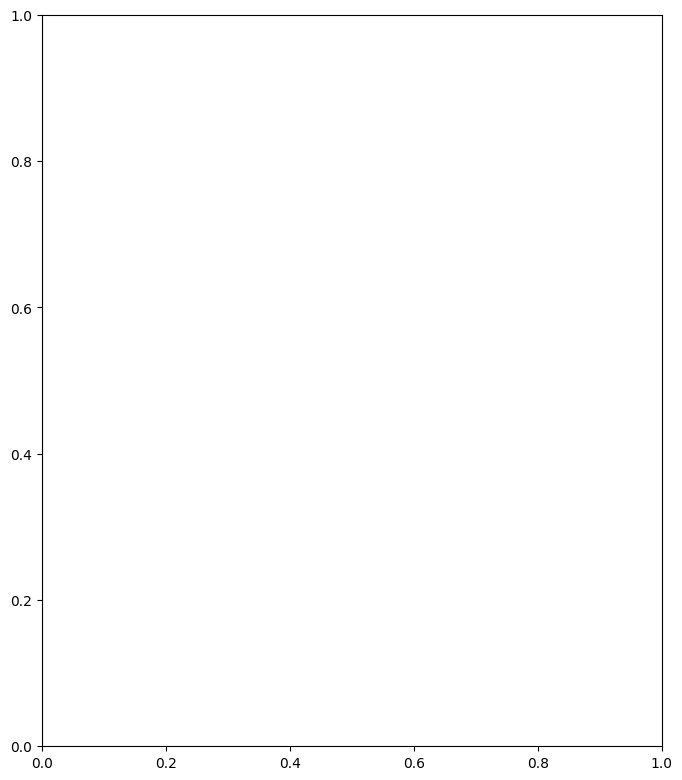

In [6]:
#shap.summary_plot(shap_values, X)

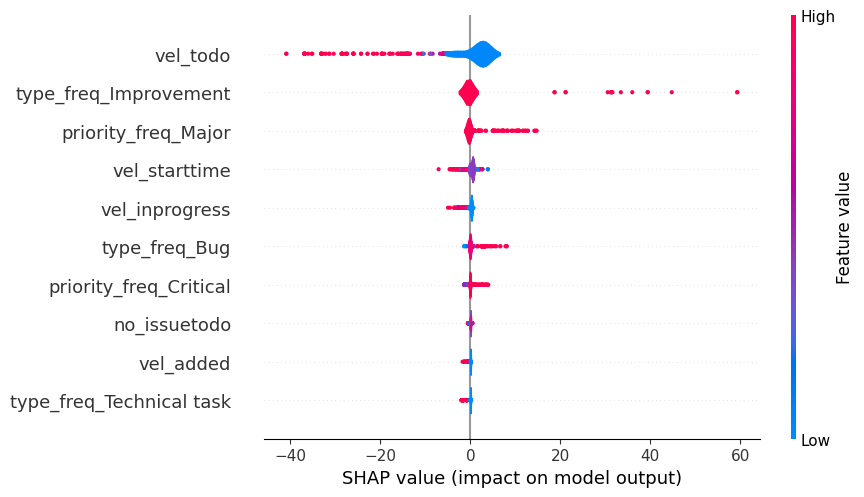

In [47]:
shap.plots.violin(shap_values, max_display=10)

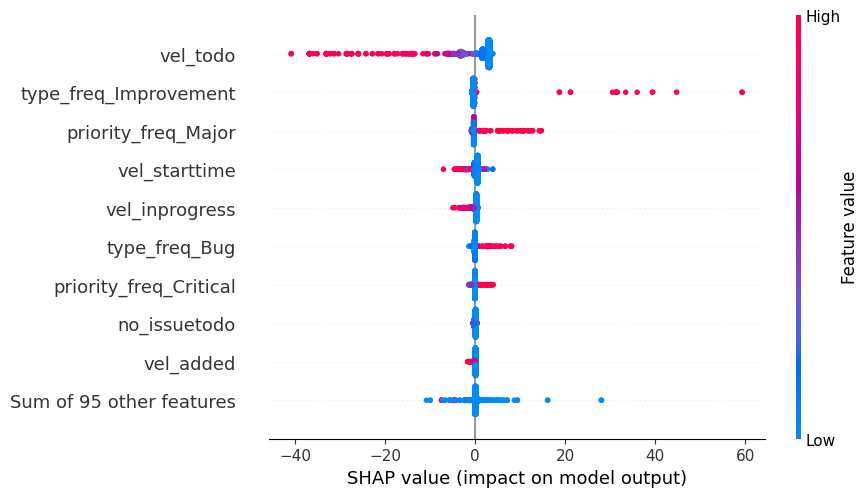

In [49]:
shap.plots.beeswarm(shap_values, max_display=10)

In [36]:
shap.initjs()
shap.plots.force(shap_values[0])

In [40]:
shap.decision_plot(explainer.expected_value, shap_values, X)

TypeError: The shap_values arg is the wrong type. Try explainer.shap_values().

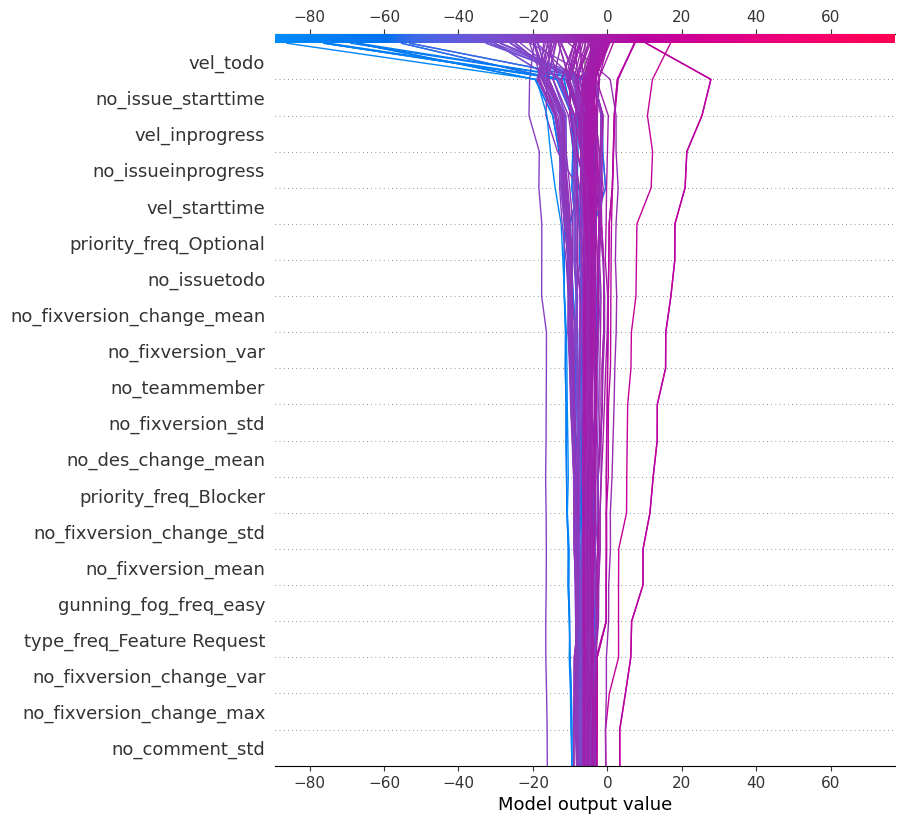

In [ ]:
shap.decision_plot(explainer.expected_value, shap_values, X)

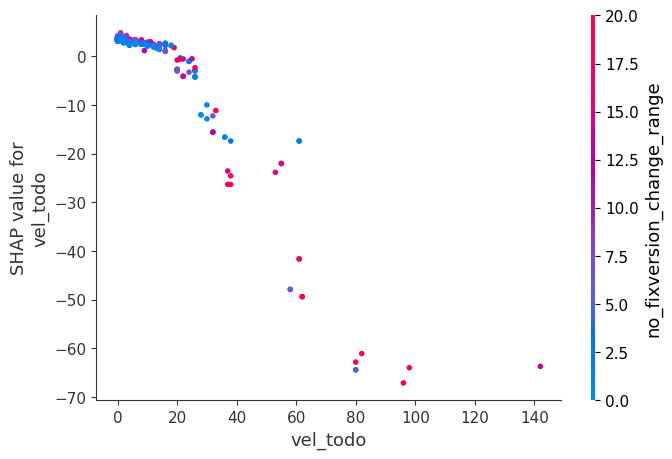

In [ ]:
shap.dependence_plot('vel_todo', shap_values, X)

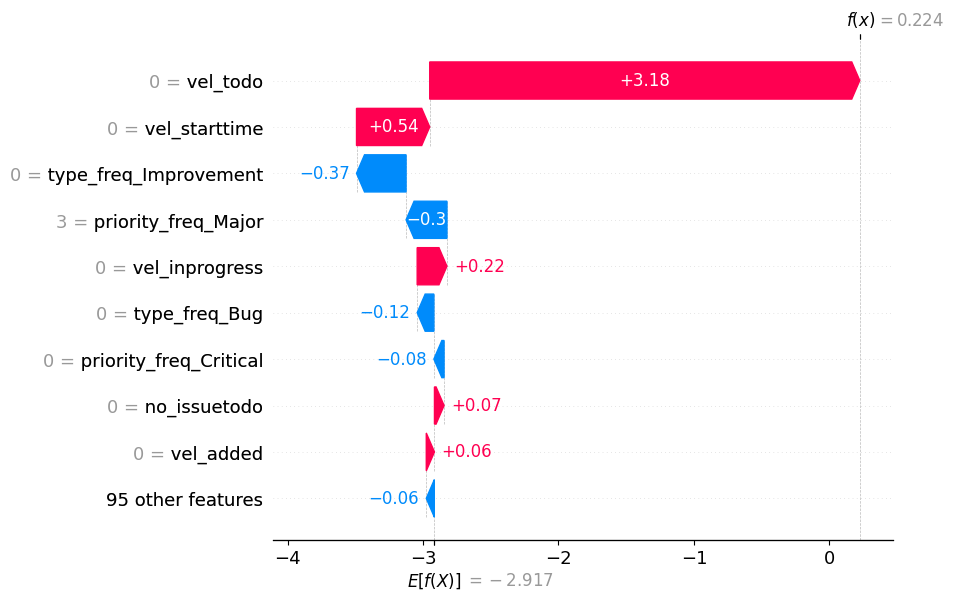

In [44]:
shap.plots.waterfall(shap_values[20])

## LIME

In [15]:
import lime
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X_train.columns.values.tolist(),
                                                  class_names=['vel_diff'], 
                                                  verbose=True, mode='regression')

In [16]:
# Choose the 5th instance and use it to predict the results
j = 5
exp = explainer.explain_instance(X_test.values[j], rf.predict, num_features=6)
exp.show_in_notebook(show_table=True)

c:\Users\viktitors\repos\sdee\venv\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 1.96661390469498
Prediction_local [0.12186143]
Right: 0.2242967389422803


In [17]:
# Choose the 5th instance and use it to predict the results
j = 10
exp = explainer.explain_instance(X_test.values[j], rf.predict, num_features=6)
exp.show_in_notebook(show_table=True)

c:\Users\viktitors\repos\sdee\venv\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 1.0683631115105798
Prediction_local [0.99387512]
Right: 0.2242967389422803


In [18]:
# Choose the 5th instance and use it to predict the results
j = 15
exp = explainer.explain_instance(X_test.values[j], rf.predict, num_features=6)
exp.show_in_notebook(show_table=True)

c:\Users\viktitors\repos\sdee\venv\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 3.4774806819261377
Prediction_local [3.90807265]
Right: 8.988787793500784


In [19]:
# Choose the 5th instance and use it to predict the results
j = 20
exp = explainer.explain_instance(X_test.values[j], rf.predict, num_features=6)
exp.show_in_notebook(show_table=True)

c:\Users\viktitors\repos\sdee\venv\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Intercept 4.290481100154261
Prediction_local [-1.90994963]
Right: -2.2170588996494676
